In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [3]:
nav = pd.read_csv("../data/processed/clean_nav.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
print("Rows :", nav.shape[0])
print("Columns :", nav.shape[1])

nav.info()

Rows : 46000
Columns : 3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


In [5]:
nav.describe()

,amfi_code,date,nav
count,46000.000000,46000,46000.000000
mean,120247.000000,2024-03-16 12:00:00.000000256,269.570265
min,100016.000000,2022-01-03 00:00:00,26.136600
25%,118632.750000,2023-02-08 00:00:00,69.170425
50%,119551.500000,2024-03-16 12:00:00,122.732150
75%,120842.250000,2025-04-23 00:00:00,260.338675
max,149324.000000,2026-05-29 00:00:00,4268.549700
std,14352.317221,NaN,577.187060


In [6]:
print("Highest NAV :", nav["nav"].max())
print("Lowest NAV  :", nav["nav"].min())
print("Average NAV :", nav["nav"].mean())

Highest NAV : 4268.5497
Lowest NAV  : 26.1366
Average NAV : 269.5702650021739


In [7]:
print("Number of Schemes :", nav["amfi_code"].nunique())

Number of Schemes : 40


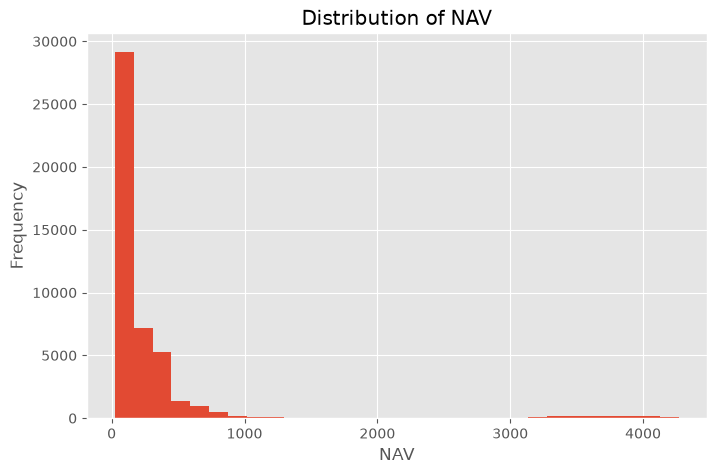

In [8]:
plt.figure(figsize=(8,5))

plt.hist(nav["nav"], bins=30)

plt.title("Distribution of NAV")
plt.xlabel("NAV")
plt.ylabel("Frequency")

plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_30268\1430313770.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(nav["nav"], vert=False)


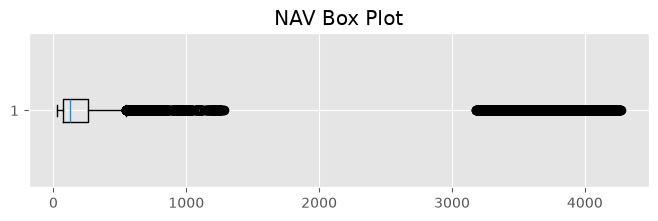

In [9]:
plt.figure(figsize=(8,2))

plt.boxplot(nav["nav"], vert=False)

plt.title("NAV Box Plot")

plt.show()

In [10]:
avg_nav = (
    nav.groupby("amfi_code")["nav"]
       .mean()
       .sort_values(ascending=False)
)

avg_nav

amfi_code
120844    3705.876331
125497     797.454477
100016     566.191221
149322     439.176645
101206     435.975472
101208     358.390923
120841     355.078750
120507     334.083952
120505     283.999240
120506     274.320937
102887     249.530563
118635     228.253463
100033     190.825330
119598     180.314069
149323     151.492094
149324     148.214974
148568     147.760011
125498     138.214296
102886     137.102766
148567     136.480609
102885     128.493803
119094     121.444471
119599     108.581372
118634     102.897924
119552     100.745458
120504      99.940254
120843      97.822895
120503      89.681075
119551      78.847733
119095      75.647006
118632      73.629655
120842      67.662844
118633      62.118409
101207      58.956796
148569      54.523904
119120      48.570406
119092      48.021952
119093      43.771809
118636      33.616353
100025      29.100359
Name: nav, dtype: float64

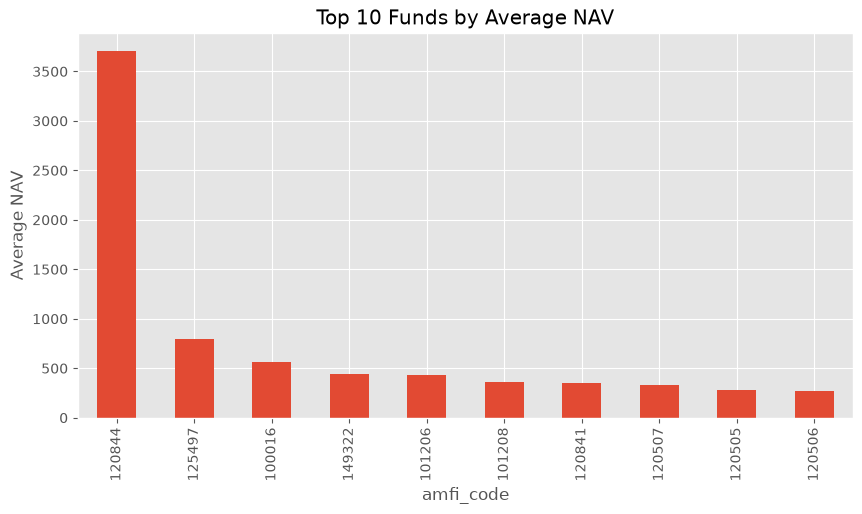

In [11]:
top10 = avg_nav.head(10)

plt.figure(figsize=(10,5))

top10.plot(kind="bar")

plt.title("Top 10 Funds by Average NAV")
plt.ylabel("Average NAV")

plt.show()

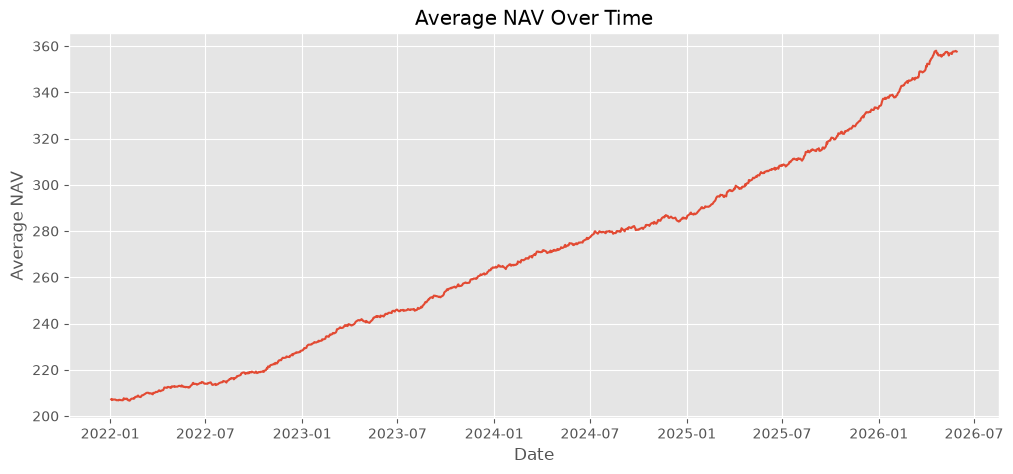

In [12]:
daily_nav = (
    nav.groupby("date")["nav"]
       .mean()
)

plt.figure(figsize=(12,5))

plt.plot(daily_nav.index, daily_nav.values)

plt.title("Average NAV Over Time")
plt.xlabel("Date")
plt.ylabel("Average NAV")

plt.show()

In [13]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change() * 100
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-1.030568
2,100016,2022-01-05,521.7239,1.286515
3,100016,2022-01-06,515.7880,-1.137747
4,100016,2022-01-07,515.1639,-0.120999


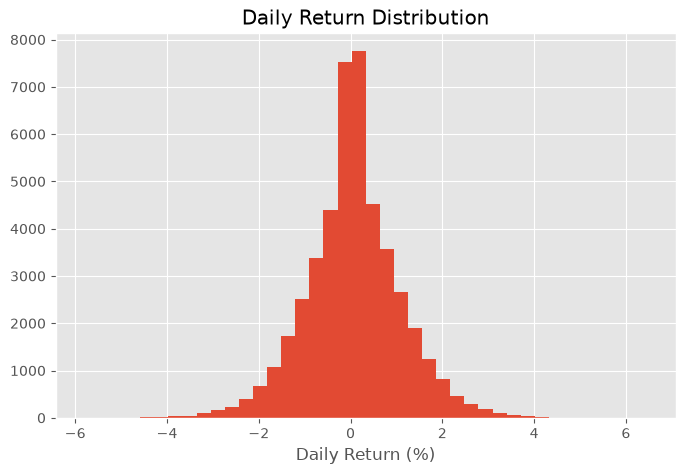

In [14]:
plt.figure(figsize=(8,5))

plt.hist(nav["daily_return"].dropna(), bins=40)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return (%)")

plt.show()

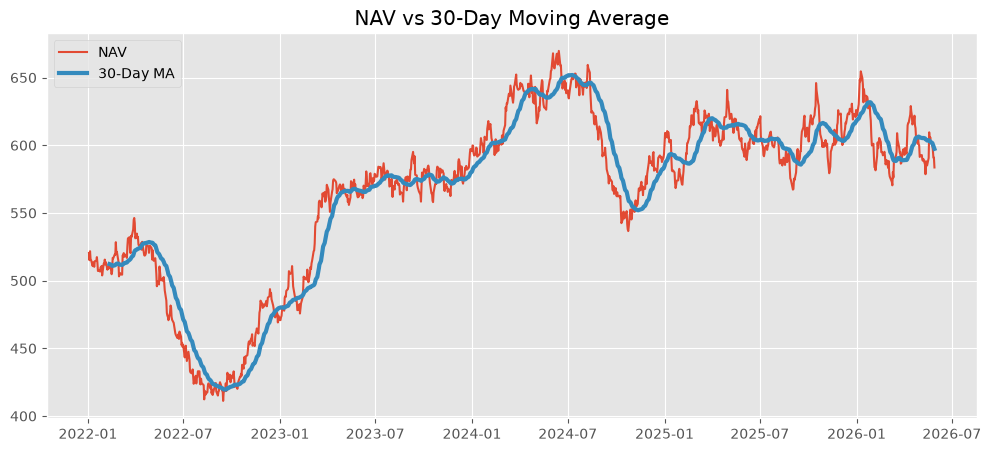

In [15]:
sample = nav[nav["amfi_code"] == nav["amfi_code"].iloc[0]].copy()

sample["moving_average"] = (
    sample["nav"]
    .rolling(30)
    .mean()
)

plt.figure(figsize=(12,5))

plt.plot(sample["date"], sample["nav"], label="NAV")

plt.plot(
    sample["date"],
    sample["moving_average"],
    linewidth=3,
    label="30-Day MA"
)

plt.title("NAV vs 30-Day Moving Average")

plt.legend()

plt.show()

## Key Insights

- The dataset contains 46,000 historical NAV records.
- NAV values vary significantly across schemes.
- The distribution of NAV is positively skewed.
- Daily returns are concentrated around zero with a few extreme movements.
- The 30-day moving average smooths short-term fluctuations and highlights the long-term trend.